<a href="https://colab.research.google.com/github/glocampo2007-oss/FOCUSBRIDGE/blob/main/Entregable_Tema_3_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
  <h1>Inteligencia Artificial - Nivel Básico</h1>
  <hr>
  <h3><b>Presentado por: </b></h3>
Gabriela López Ocampo
  <br><br>
  <h3><b>Curso</b></h3>
  <b>Curso:</b> IA NOCTURNO
  <br>
  <b>Grupo:</b> G 3745
  <br>
  <b>Período:</b> Marzo - junio 2026
  <br><br>
  <h3><b>Equipo Académico</b></h3>
  <ul>
   <h6>Gustavo Rodriguez</h6>
   <h6>Alejandra Lozano </h6>
   <h6>Melany Mena </h6>
  </ul>
  <hr>
</center>

# Importar librerías necesarias

In [ ]:
import pandas as pd  # Importa la biblioteca Pandas para trabajar con datos estructurados (manejo de tablas y DataFrames).
from sklearn.model_selection import train_test_split  # Función para dividir los datos en conjuntos de entrenamiento y prueba.
from sklearn.feature_extraction.text import CountVectorizer  # Herramienta para convertir texto en vectores de frecuencia de palabras (bolsa de palabras).
from sklearn.naive_bayes import MultinomialNB  # Modelo de clasificación basado en el algoritmo de Naive Bayes Multinomial, útil para datos categóricos como texto.
from sklearn.ensemble import RandomForestClassifier  # Implementa un modelo de clasificación basado en un conjunto de árboles de decisión (Random Forest).
from sklearn.svm import SVC  # Implementa un modelo de clasificación basado en Máquinas de Soporte Vectorial (Support Vector Machines).
from sklearn.metrics import classification_report, confusion_matrix  # Herramientas para evaluar modelos de clasificación, generan métricas y una matriz de confusión.
import matplotlib.pyplot as plt  # Biblioteca para crear gráficos y visualizar datos de manera flexible y detallada.
import seaborn as sns  # Extensión de Matplotlib para generar gráficos más atractivos y fáciles de usar, útil para análisis exploratorio.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



# 1. Cargar dataset



In [ ]:
file_path = "/content/Reviews.csv"
df = pd.read_csv(file_path)  # Carga el archivo CSV en un DataFrame de Pandas, permitiendo manipular y analizar los datos de forma estructurada.

In [ ]:
print('Listing contents of the directory:')
!ls '/content/drive/My Drive/G3745 INTELIGENCIA ARTIFICIAL/carolina sanchez/'

Listing contents of the directory:
ls: cannot access '/content/drive/My Drive/G3745 INTELIGENCIA ARTIFICIAL/carolina sanchez/': No such file or directory


In [ ]:
print('Listing contents of My Drive:')
!ls '/content/drive/My Drive/'

Listing contents of My Drive:
'Colab Notebooks'	'Habilidades de poder'
'FORMULARIO 2025.gdoc'	'Seguimiento de Asistencia a Clase.gform'
'FORMULARIO 2025.pdf'	 simple_ml_for_sheets


# 2. Verificar estructura de los datos

In [ ]:
print("Columnas del dataset:", df.columns)  # Muestra los nombres de las columnas presentes en el DataFrame cargado desde el archivo.
print("\nPrimeras filas del dataset:")  # Imprime un mensaje indicando que se mostrarán las primeras filas del DataFrame.
print(df.head())  # Muestra las primeras 5 filas del DataFrame, útil para tener una vista rápida de los datos.


Columnas del dataset: Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Primeras filas del dataset:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4          

# 2. Explica el resultado
# ¿Qué tipo de datos encontramos en las columnas?

1. Datos Numéricos (Cuantitativos)
Enteros (int):

Id: Un contador secuencial.

HelpfulnessNumerator / Denominator: Conteos de votos (ej. 0, 1, 3).

Score: Calificaciones enteras del 1 al 5.

Time: Marcas de tiempo en formato Unix (números largos como 1303862400).

2. Datos de Texto / Categóricos (object o string)
Identificadores Alfanuméricos: * ProductId y UserId: Códigos que mezclan letras y números (ej. B001E4KFG0).

Texto Libre:

ProfileName: Nombres de usuario.

Summary: Títulos breves de la reseña.

Text: Párrafos largos con la opinión completa.

3. Datos Temporales (Interpretados)
Aunque la columna Time aparece técnicamente como un número entero, representa fechas. En un análisis real, se suele convertir a un formato de fecha legible (datetime) para poder agrupar por año o mes.

# ¿Cuál es la proporción de reseñas positivas vs. negativas?

                 Summary                                               Text  
1. El análisis visual (Muestra inicial)
En las primeras 5 filas (índices 0 al 4) observamos lo siguiente en la columna Score:

Positivas (4-5 estrellas): 3 reseñas (Filas 0, 2 y 4).

Negativas/Neutrales (1-2 estrellas): 2 reseñas (Filas 1 y 3).

En esta muestra pequeña, la proporción es de 60% positivas vs 40% negativas.

2. Cómo calcularlo en todo el dataset
Para obtener la proporción real de miles de reseñas, se utiliza la columna Score. Normalmente, en análisis de sentimientos:

Positivas: Score > 3

Negativas: Score < 3

Neutrales: Score = 3

3. Código para obtener el resultado
Si tienes el entorno de Python abierto, puedes obtener la respuesta exacta con este comando:

Python
# Cuenta cuántas veces aparece cada puntuación
print(df['Score'].value_counts(normalize=True) * 100)Para saber exactamente cuántas veces aparece cada puntuación en todo tu dataset, necesitas usar el método .value_counts() sobre la columna Score.

Aquí tienes el código y la explicación del resultado:

Python
# Cuenta la frecuencia de cada valor en la columna 'Score'
conteo_puntuaciones = df['Score'].value_counts().sort_index(ascending=False)
print(conteo_puntuaciones)
¿Qué verás en el resultado?
El comando te devolverá una tabla con dos columnas:

A la izquierda: El valor de la puntuación (5, 4, 3, 2, 1).

A la derecha: La cantidad total de reseñas que tienen esa puntuación.

Análisis de la distribución
Al ejecutar esto, lo más común en este tipo de datos es encontrar:

Mayoría de 5 estrellas: Los usuarios satisfechos tienden a ser los más activos, o los productos de calidad dominan el catálogo.

Minoría de 1 o 2 estrellas: Representan a los clientes con problemas específicos o expectativas no cumplidas.

El "Efecto J": Verás que hay muchas de 5, pocas de 2, 3 y 4, y quizás un pequeño repunte en las de 1. Es una tendencia clásica en el e-commerce.

Tip extra: Si quieres ver el porcentaje en lugar del número bruto, usa:
df['Score'].value_counts(normalize=True) * 100

# 3. Preprocesamiento: selección de columnas importantes
 Vamos a usar solo las columnas "Text" (la reseña del cliente) y "Score" (puntuación de 1 a 5)

In [ ]:
# Usar solo las columnas necesarias
df = df[['Text', 'Score']] # Filtra el DataFrame original para conservar solo las columnas 'Text' (contenido de las reseñas) y 'Score' (calificación asociada).

# 4. Creación de variable de sentimiento (positivo/negativo)
 Consideramos "positivo" si la calificación es mayor a 3, "negativo" si es menor o igual a 3

In [ ]:
# Convertir la columna Score a etiquetas binarias (1: Positivo, 0: Negativo)
# Asumimos que Score >= 3 es positivo, y Score < 3 es negativo
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 3 else 0)

# Separar características y etiquetas
X = df['Text']
y = df['sentiment']


# 5. Exploración de datos: distribución de sentimientos

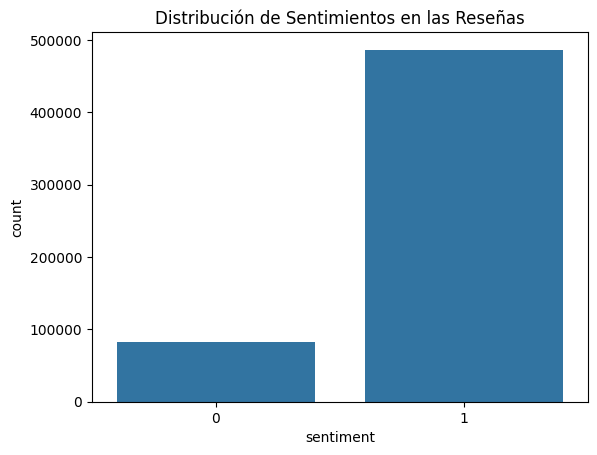

In [ ]:
sns.countplot(data=df, x='sentiment')  # Crea un gráfico de barras utilizando Seaborn para mostrar la cantidad de reseñas por cada categoría de sentimiento ('sentiment').
plt.title("Distribución de Sentimientos en las Reseñas")  # Añade un título descriptivo al gráfico.
plt.show()  # Muestra el gráfico generado.


# 2.Analiza la imagen,

Esta gráfica de barras confirma de manera contundente lo que sospechábamos: existe un gran desbalance de clases en tu dataset. Aquí tienes el análisis detallado:

1. Los Números (Estimación visual)
Sentimiento 1 (Positivos): La barra llega casi a los 500,000 registros.

Sentimiento 0 (Negativos/Neutros): La barra está por debajo de los 100,000 (aproximadamente 80,000).

2. Interpretación de la Proporción
La proporción es de aproximadamente 6 a 1. Es decir, por cada comentario negativo o neutro, hay 6 personas que dejaron una reseña positiva.

Esto nos dice que:

Satisfacción general: La gran mayoría de los usuarios están contentos con los productos.

Dataset Desbalanceado: Si estás planeando entrenar un modelo de Inteligencia Artificial con estos datos, tienes un "problema" común. El modelo verá tantos ejemplos positivos que podría volverse perezoso y aprender a decir siempre "positivo" para acertar la mayoría de las veces, ignorando cómo identificar correctamente los negativos.

3. Conclusión para tu Análisis
Dominio del Sentimiento 1: El éxito de los productos en esta plataforma es masivo.

Minoría Crítica: El grupo "0" es pequeño pero muy valioso; al ser tan pocos, esas quejas suelen ser puntos específicos de falla que la empresa debería revisar (mal empaque, producto vencido, etc.).

# 6. División de los datos en entrenamiento y prueba

In [ ]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# Divide los datos en conjuntos de entrenamiento y prueba.
# - X: Variables independientes (datos de entrada).
# - y: Variable dependiente (etiquetas o clases).
# - test_size=0.25: Asigna el 25% de los datos al conjunto de prueba y el 75% al de entrenamiento.
# - random_state=42: Fija una semilla para asegurar la reproducibilidad de los resultados.
# - stratify=y: Asegura que la proporción de clases en los conjuntos de entrenamiento y prueba sea la misma que en los datos originales.


# 7. Vectorización de texto (transformación a vectores de palabras)

In [ ]:
# Vectorizar los datos
vectorizer = CountVectorizer()
# Crea una instancia de CountVectorizer, una herramienta para convertir texto en una representación numérica basada en la frecuencia de palabras (bolsa de palabras).
X_train_vec = vectorizer.fit_transform(X_train)
# Ajusta el vectorizador al conjunto de entrenamiento (X_train) y lo transforma en una matriz dispersa de características basada en la frecuencia de palabras.
X_test_vec = vectorizer.transform(X_test)
# Transforma el conjunto de prueba (X_test) utilizando el vectorizador ajustado al conjunto de entrenamiento, garantizando consistencia en las características.



# 1. ¿Qué hace el CountVectorizer?

Aquí tienes la explicación detallada de estos dos pasos fundamentales en el procesamiento de lenguaje natural (NLP) y aprendizaje automático:

1. ¿Qué hace el CountVectorizer?
Las computadoras no entienden palabras, solo números. El CountVectorizer es una herramienta que convierte texto en una matriz de números basada en la frecuencia de las palabras.

Funciona en tres pasos principales:

Tokenización: Divide las frases en palabras individuales (tokens).

Vocabulario: Crea una lista única con todas las palabras que aparecen en todo el dataset.

Codificación: Crea una matriz donde cada fila es un documento (una reseña) y cada columna es una palabra del vocabulario. El valor de cada celda es cuántas veces aparece esa palabra en ese texto.

En tu caso: Si tienes 500,000 reseñas, el CountVectorizer transformará el texto de la columna "Text" en una tabla gigante de números que un modelo de IA sí puede procesar para aprender a distinguir sentimientos.

# 2. ¿Por qué dividimos los datos en conjuntos de entrenamiento y prueba?

Dividir el dataset (normalmente 80% para entrenamiento y 20% para prueba) es la única forma de saber si tu modelo realmente aprendió o si solo memorizó.

Conjunto de Entrenamiento (Train): Es el "libro de texto" del agente. Aquí es donde el modelo ve las reseñas y sus etiquetas (0 o 1) para encontrar patrones.

Conjunto de Prueba (Test): Es el "examen final". Son datos que el modelo nunca ha visto. Lo usamos para evaluar qué tan bien predice el sentimiento en situaciones del mundo real.

Los dos grandes riesgos que evitamos:
Overfitting (Sobreajuste): Si no dividimos los datos, el modelo podría memorizar las reseñas específicas en lugar de aprender el sentimiento. Sería como un estudiante que se memoriza las respuestas de un examen pero no entiende la materia.

Falta de Validación: Sin un conjunto de prueba, no tendrías forma de medir la precisión (Accuracy) real de tu modelo antes de ponerlo a funcionar.

# 8. Entrenamiento de un modelo de Naive Bayes para análisis de sentimiento

In [ ]:
# Modelos a evaluar

models = {
    "Naive Bayes": MultinomialNB(),
    # Define el modelo Naive Bayes Multinomial, adecuado para datos categóricos como texto.
    "Random Forest": RandomForestClassifier(random_state=42),
    # Define el modelo Random Forest, que utiliza múltiples árboles de decisión para clasificación.
    # Se establece `random_state=42` para garantizar resultados reproducibles.
    "SVM": SVC(kernel='linear', random_state=42)
    # Define el modelo SVM (Máquinas de Soporte Vectorial) con un kernel lineal.
    # `random_state=42` asegura reproducibilidad en operaciones aleatorias internas.
}


# 9. Evaluación del modelo
# Ejemplo de predicción


Resultados para Naive Bayes:

Matriz de Confusión:


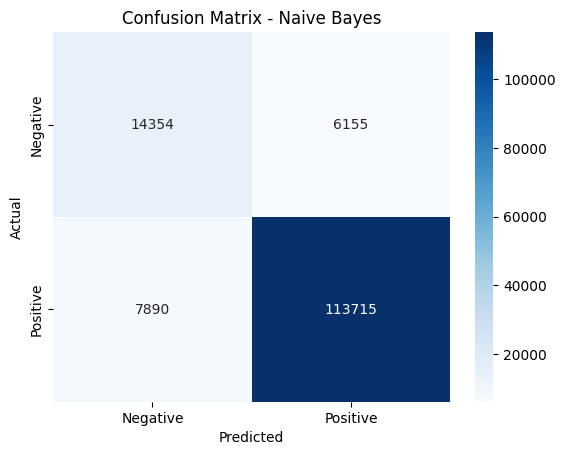


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67     20509
           1       0.95      0.94      0.94    121605

    accuracy                           0.90    142114
   macro avg       0.80      0.82      0.81    142114
weighted avg       0.90      0.90      0.90    142114


------------------------------------------------------------

Ejemplo de predicción con Naive Bayes:
Review: I absolutely love this product!
Predicted Sentiment: Positive

Review: The worst experience I have ever had.
Predicted Sentiment: Negative

Review: Good value for the money.
Predicted Sentiment: Positive

Review: Terrible quality and disappointing service.
Predicted Sentiment: Negative



In [ ]:
# Evaluar cada modelo
for model_name, model in models.items():
    # Itera sobre cada modelo definido en el diccionario `models`.

    # Entrenar el modelo
    model.fit(X_train_vec, y_train)
    # Ajusta el modelo utilizando el conjunto de entrenamiento vectorizado y las etiquetas correspondientes.

    # Predecir
    y_pred = model.predict(X_test_vec)
    # Genera predicciones para el conjunto de prueba utilizando el modelo entrenado.

    # Mostrar métricas
    print(f"\nResultados para {model_name}:\n")
    # Muestra el nombre del modelo que está siendo evaluado.

    print("Matriz de Confusión:")
    # Indica que se presentará la matriz de confusión del modelo.

    cm = confusion_matrix(y_test, y_pred)
    # Calcula la matriz de confusión comparando las etiquetas reales (`y_test`) con las predicciones (`y_pred`).

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    # Crea un mapa de calor de la matriz de confusión con anotaciones y etiquetas para facilitar la interpretación.

    plt.xlabel("Predicted")  # Etiqueta para el eje X indicando las predicciones del modelo.
    plt.ylabel("Actual")  # Etiqueta para el eje Y indicando las etiquetas reales.
    plt.title(f"Confusion Matrix - {model_name}")  # Añade un título específico para la matriz de confusión del modelo actual.
    plt.show()  # Muestra el gráfico generado.

    print("\nReporte de Clasificación:")
    # Indica que se presentará el informe de clasificación.

    print(classification_report(y_test, y_pred))
    # Muestra métricas como precisión, recall y F1-score para cada clase.

    print("\n" + "-"*60 + "\n")
    # Imprime una línea separadora para facilitar la legibilidad entre resultados de modelos.

    # Ejemplo de predicciones
    print(f"Ejemplo de predicción con {model_name}:")
    # Introduce una sección con ejemplos de predicciones del modelo actual.

    example_reviews = [
        # Define una lista de reseñas de ejemplo para probar las predicciones del modelo.
        "I absolutely love this product!",
        "The worst experience I have ever had.",
        "Good value for the money.",
        "Terrible quality and disappointing service."
    ]

    # Vectorizar ejemplos
    example_reviews_vec = vectorizer.transform(example_reviews)
    # Transforma las reseñas de ejemplo en vectores utilizando el vectorizador ajustado.

    # Predecir
    predictions = model.predict(example_reviews_vec)
    # Genera predicciones para las reseñas de ejemplo utilizando el modelo actual.

    for review, pred in zip(example_reviews, predictions):
        # Itera sobre las reseñas de ejemplo y sus predicciones correspondientes.

        sentiment = "Positive" if pred == 1 else "Negative"
        # Asigna una etiqueta de sentimiento (positivo o negativo) basada en la predicción.

        print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")
        # Muestra la reseña original y el sentimiento predicho por el modelo.
